# Model Uncertainty

Any model which makes some predictions about the real world does so with a certain uncertainty/room for error.

In this example we explore the uncertainty of the estimates given by PalmSim.

We will do so by running PalmSim multiple times with slightly different parameter choices and consider how this affects the estimates.

As such we take into account both model sensitivity and our uncertainty about certain parameters: a holistic approach.

Note, this gives a lower bound on the model uncertainty: we assume unwarrantedly that the model itself is correct.

The only real test is comparison with reality!

Still the value of such a 'Monte Carlo' approach should be self-evident:

we can effectively identify what is/is not important in improving the accuracy of the model.

For the consideration of only the model sensitivity, see the example "sensitivity analysis".

## What we expect

It turns out the model is (as is to be expected) relatively sensitive to the choice of the parameters:
    - k --- the parameter which sets light interception as a function of leaf area index
    - LUE --- the light use efficiency (g assimilate / MJ PAR)
    - growth/maintenance respiration coefficients --- the cost of respiration

Note, this holds for all crop models that involve these parameters.

<img src="images/hoffman_diagram.png" alt="" width=400>


### This Example   

This example has the following outline and will consider the potential production scenario:

    1. We have a look at input **weather data** for a site in North Sumatra.
    2. We run the model multiple times with different parameter values
    3. We plot the different outcomes
 

## Weather data

This demo comes with weather data files which can be found in the inputs folder.

Here we consider weather data for North Sumatra.

In [1]:
# to allow us to work with spreadsheets import the "pandas" library
import pandas as pd

# to allow us to make plots, import a plotting library
import matplotlib.pyplot as plt

# read-in the csv-file
weather_data = pd.read_csv('./input/north_sumatra.csv',index_col='Date')
weather_data.index = pd.to_datetime(weather_data.index)

In [2]:
list(weather_data)

['Precip (mm)', 'Solar (MJ/m2)']

### Solar Radiation

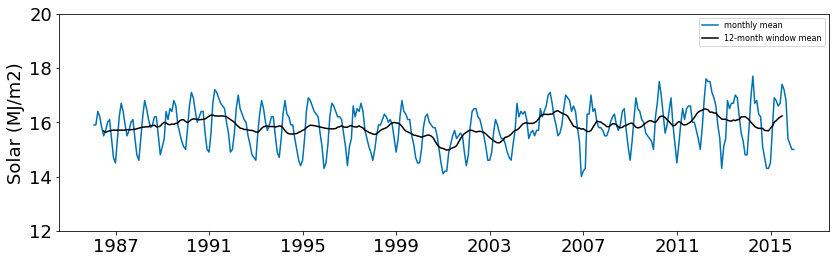

In [3]:
from plotting import tsplot

f,ax = tsplot(weather_data,'Solar (MJ/m2)')
ax.set_ylim(12,20)
    
plt.tight_layout()

## Potential Yield - best estimate

Now let us run PalmSim given this solar radiation to calculate the potential yield.

In [4]:
import sys
sys.path.append('../PalmSim')
sys.path.append('..')
from PalmField import PalmField

year_of_planting = weather_data.index.year[0]

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

# 2. Couple the solar radiation data:
p.weather.radiation_series = weather_data['Solar (MJ/m2)']

# 3. Run the model
df = p.run(duration=360,)

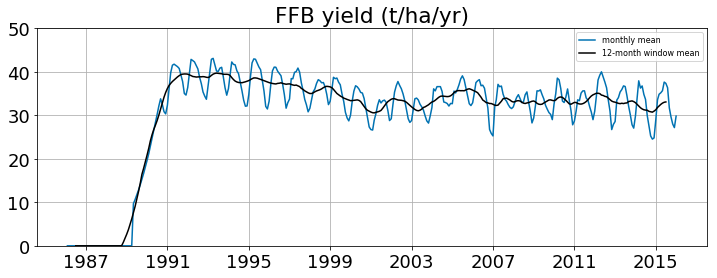

In [5]:
f,ax = tsplot(df,'organs yield FM yearly (tonne FM/ha/year)')
ax.set_ylabel('')
ax.set_title('FFB yield (t/ha/yr)')
ax.set_ylim(0,50)
ax.grid()

# Potential Yield - Model Uncertainty

Now let us consider how this production responds to different choices for a number of key parameters.

In [6]:
# to easily change all the model parameters
# let us get the following helper functions

from PalmField import get_parameters, set_parameters
from copy import deepcopy

default_parameters = get_parameters()

In [7]:
# The parameters are categorized by sub-model:

print(list(default_parameters))

['fronds', 'trunk', 'roots', 'organs', 'assimilates', 'management', 'soil', 'weather', 'indeterminate', 'male', 'female', 'stalk', 'mesocarp_fibers', 'mesocarp_oil', 'kernel']


In [8]:
# Each sub-model then has a number of parameters:
list(default_parameters['fronds'])

['specific_maintenance_rachis',
 'specific_maintenance_leaflets',
 'conversion_efficiency',
 'fraction_rachis',
 'fraction_leaflets',
 'specific_leaf_area',
 'LUE',
 'WUE',
 'k',
 'leaf_area_a',
 'leaf_area_b',
 'leaf_area_c',
 'initiation_rate_a',
 'initiation_rate_b',
 'initiation_rate_c',
 'initiation_rate_max',
 'opening_age',
 'potential_growth_rate']

In [9]:
# Each parameter comes with the necessary information
default_parameters['fronds']['LUE']

{'info': 'The light use efficiency.',
 'source': 'Based on a more detailed hourly light-response model (copied from SUCROS) using oil palm LR measurements by Breure, Gerritsma.',
 'uncertainty': '10%',
 'unit': 'tonne_CH2O/TJ',
 'value': 4.2}

In [10]:
# The parameters that we will vary
params = [('fronds','LUE'),
           ('fronds','k'),
          
           ('fronds','conversion_efficiency'),
           ('fronds','potential_growth_rate'),
           
           ('trunk','conversion_efficiency'),
           ('trunk','potential_growth_rates'),
            
           ('roots','conversion_efficiency'),
           ('roots','potential_growth_rate'),
            
           ('mesocarp_oil','conversion_efficiency'),
           ('kernel','conversion_efficiency'),
           ]

# Picking parameters with uncertainty

In [11]:
# A helper function to pick parameters with uncertainty
import numpy as np
def draw_parameters(default_parameters,which=None):
    ''' Draws parameters taking into account parameter uncertainty. '''

    parameters = deepcopy(default_parameters)

    if which is None:
        return res
    
    for k1,k2 in which:

        param_info = parameters[k1][k2]
        if 'uncertainty' not in param_info:
            print('Missing info:', k1,k2)
            continue       

        value = parameters[k1][k2]['value']

        # Some text -> number manipulation
        # "10%" --> "10" --> 10 --> 0.1
        relstd2 = 0.01*float(parameters[k1][k2]['uncertainty'][0:-1])        
        relstd = 0.5*relstd2
        
        # e.g. relstd = 0.01 = within +-1% with around 60% certainty  
        
        if isinstance(value,list):
            # assume of the form [[x0,y0],[xn,yn]]
            
            value = [[x[0],x[1]*np.random.normal(1,relstd)] for x in value]
        
        else:
            
            value = value * np.random.normal(1,relstd)
         
        parameters[k1][k2]['value'] = value
        
    return parameters

In [12]:
parameters = draw_parameters(default_parameters,which=params)

### With the helper function done...

Now we can pick/draw parameters taking into account our uncertainty on them!

In [13]:
for i in range(3):
    print('Run: ', i)
    parameters = draw_parameters(default_parameters,which=params)
    for k1,k2 in params:
        value = parameters[k1][k2]['value']
        
        if isinstance(value,list):
            for i in range(len(value)):
                print('\t{:<10.10} {:<28.28}{:<2}: {:<+3.4f}'.format(k1,k2,i,value[i][1]))
        else:

            print('\t{:<10.10} {:<30.30}: {:<+3.4f}'.format(k1,k2,value))

Run:  0
	fronds     LUE                           : +4.3399
	fronds     k                             : +0.3269
	fronds     conversion_efficiency         : +0.6757
	fronds     potential_growth_rate         : +0.0077
	trunk      conversion_efficiency         : +0.6892
	trunk      potential_growth_rates      0 : +1.1098
	trunk      potential_growth_rates      1 : +1.0842
	trunk      potential_growth_rates      2 : +1.0923
	trunk      potential_growth_rates      3 : +0.8939
	trunk      potential_growth_rates      4 : +0.6407
	trunk      potential_growth_rates      5 : +0.2285
	roots      conversion_efficiency         : +0.6948
	roots      potential_growth_rate         : +0.0014
	mesocarp_o conversion_efficiency         : +0.4172
	kernel     conversion_efficiency         : +0.4381
Run:  1
	fronds     LUE                           : +4.5225
	fronds     k                             : +0.3133
	fronds     conversion_efficiency         : +0.6885
	fronds     potential_growth_rate         : +0.0

## Running the model

Accordingly we can run the model multiple times taking into account the uncertainty about the parameter values.

In [14]:
# Number of runs --- might take some time, good moment to get some tea
N = 40

# A. Define a list to store the results
dfs = []

# B. Run the control: default parameter values

# 1. Initialize the model
p = PalmField(year_of_planting=year_of_planting)

set_parameters(default_parameters)

# 2. Couple the solar radiation data:
p.weather.radiation_series = weather_data['Solar (MJ/m2)']

# 3. Run the simulation
df = p.run(duration=360,)

# 4. Store the result
dfs.append(df)

# D. Run the parameter variations:
for i in range(N):
    
    print('.',end='')
    if i%20 == 0:
        print()
    
    parameters = draw_parameters(default_parameters,which=params)
    
    set_parameters(parameters)
        
    # 1. Initialize the model
    p = PalmField(year_of_planting=year_of_planting)

    # 2. Couple the solar radiation data:
    p.weather.radiation_series = weather_data['Solar (MJ/m2)']
    
    # 3. Run the simulation
    df = p.run(duration=360,)
    
    # 4. Store the result
    dfs.append(df)

.
....................
...................

## Results

Now let us analyze the results

In [15]:
# To do so let us make a small helper function to make a nice plot

def make_plot(column, mean=False, 
                      title=None,
                      ax=None,
                      figsize=(8,4),
                      alpha=None):
    ''' Makes a plot of the given data column. '''

    if ax is None:
        f,ax = plt.subplots(figsize=figsize)
    else:
        pass
        
    c = column

    yc = dfs[0][c]

    if mean:    
        yc = yc.rolling(12,center=True).mean()
        
    ax.plot(yc,label='best est.',color='black',ls='dashed')

    ub = 1.1*yc
    lb = 0.9*yc
    
    ax.plot(ub,label='+10%',color='black',ls='dotted')
    ax.plot(lb,label='- 10%',color='black',ls='dotted')

    if alpha is None:
        alpha = 5/len(dfs)

    ax.legend()

    for df in dfs:
        y = df[c]
        
        if mean:    
            y = y.rolling(12,center=True).mean()
        
        ax.plot(y,color='teal',alpha=alpha,label=None)

    ax.grid()

    if title is None:
        pass
    else:
        ax.set_title(title);
        
    return ax

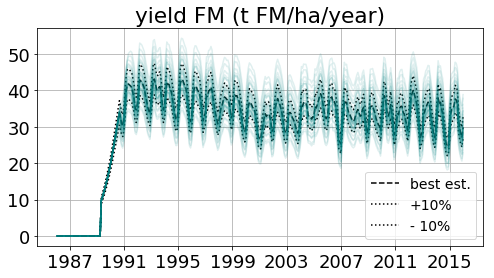

In [16]:
c = 'organs yield FM yearly (tonne FM/ha/year)'
make_plot(c,title='yield FM (t FM/ha/year)')

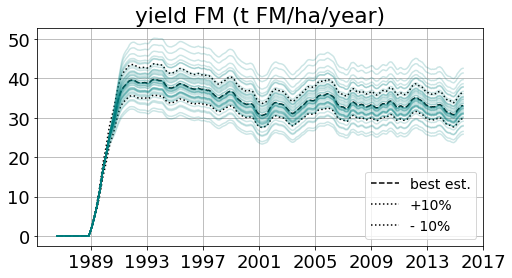

In [17]:
c = 'organs yield FM yearly (tonne FM/ha/year)'
make_plot(c,title='yield FM (t FM/ha/year)',mean=True, alpha=0.2)
plt.savefig('model_uncertainty.png',dpi=300)

In [18]:
import datetime
def xys_to_datetime(xys,offset=1986):
    return np.array([[datetime.datetime(year= int(divmod(xy[0],1)[0]+offset),
                                        month= int(1+12*divmod(xy[0],1)[1]),
                                        day = 1),xy[1]] for xy in xys])

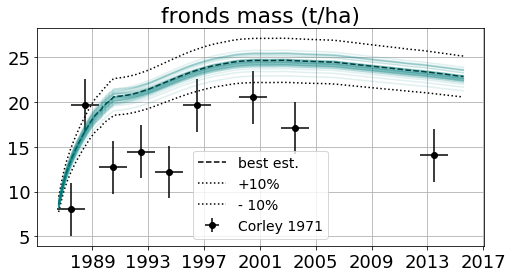

In [25]:
f,ax = plt.subplots(figsize=(8,4))

# Corley 1971, kg/palm
rho1 = 122
rho2 = 148
observed = ([
            [1.5,rho2*54],
            [2.5,rho2*132.7],
            [4.5,rho1*104.2],
            [6.5,rho1*118.4],
            [8.5,rho1*99.9],
            [10.5,rho1*161.1],
            [14.5,rho1*168.2],
            [17.5,rho1*140.2],
            [27.5,rho1*115.4]])

xys = xys_to_datetime(observed)

x = xys[:,0]
y = 0.001*xys[:,1] # planting density, convert to tonnes
xerr = datetime.timedelta(days=365)
yerr = rho2*20*0.001

ax.errorbar(x,y,xerr=xerr,yerr=yerr,fmt='o',color='black',label='Corley 1971')

c = 'fronds mass (t/ha)'
ax = make_plot(c,title=c,mean=True,ax=ax)

plt.savefig('output/fronds_mass.png',dpi=300)

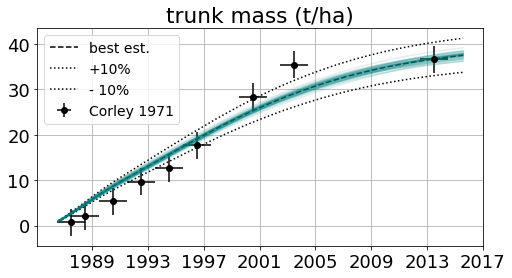

In [26]:
f,ax = plt.subplots(figsize=(8,4))

# Corley 1971, kg/palm
rho1 = 122
rho2 = 148
observed = ([
            [1.5,rho2*4.7],
            [2.5,rho2*13.8],
            [4.5,rho1*43.6],
            [6.5,rho1*78.9],
            [8.5,rho1*103.7],
            [10.5,rho1*145.3],
            [14.5,rho1*232.6],
            [17.5,rho1*290.7],
            [27.5,rho1*300.5]])

xys = xys_to_datetime(observed)

x = xys[:,0]
y = 0.001*xys[:,1] # planting density, convert to tonnes
xerr = datetime.timedelta(days=365)
yerr = rho2*20*0.001

ax.errorbar(x,y,xerr=xerr,yerr=yerr,fmt='o',color='black',label='Corley 1971')

c = 'trunk mass (t/ha)'
ax = make_plot(c,title=c,mean=True,ax=ax)

plt.savefig('output/trunk_mass.png',dpi=300)

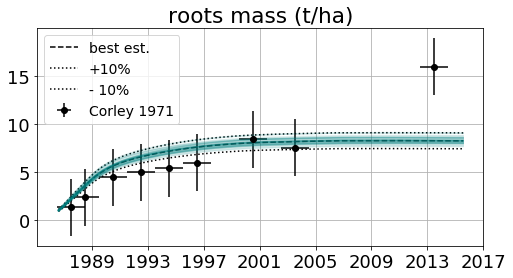

In [27]:
f,ax = plt.subplots(figsize=(8,4))

# Corley 1971, kg/palm
rho1 = 122
rho2 = 148
observed = ([
            [1.5,rho2*8.8],
            [2.5,rho2*15.9],
            [4.5,rho1*36.4],
            [6.5,rho1*40.6],
            [8.5,rho1*44.0],
            [10.5,rho1*49.0],
            [14.5,rho1*68.9],
            [17.5,rho1*61.6],
            [27.5,rho1*130.8]])

xys = xys_to_datetime(observed)

x = xys[:,0]
y = 0.001*xys[:,1] # planting density, convert to tonnes
yerr = rho2*20*0.001

ax.errorbar(x,y,xerr=xerr,yerr=yerr,fmt='o',color='black',label='Corley 1971')

c = 'roots mass (t/ha)'
ax = make_plot(c,title=c,mean=True,ax=ax)

plt.savefig('output/roots_mass.png',dpi=300)